# Engle-Granger Cointegration Analysis

### Purpose
Apply Engle-Granger on three highly correlated stock pairs identified during EDA phase:
Pairs are:
1. MA vs V
2. HD vs LOW
3. AMAT vs LRCX

- Replacing three pairs with hundreds requires only changing `CANDIDATE_PAIRS`.
- Data is loaded from EDA-produced files.
- Results are stored in a structured DataFrame and exported to CSV.

---

## 1. Import Libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.graphics.tsaplots import plot_acf

import os
import warnings

from typing import Tuple, Dict

warnings.filterwarnings("ignore")

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load & Validate Data

Adjusted closing prices are loaded from the processed files produced during the EDA phase.

**Validation checks performed:**
- End-date alignment between price and return datasets
- Expected row-count difference due to `pct_change()`

In [82]:
adj_close = pd.read_csv("../data/cleaned/adj_close_cleaned.csv", index_col=0, parse_dates=True)

returns = pd.read_csv("../data/processed/returns.csv", index_col=0, parse_dates=True)

# Basic Validation
assert adj_close.index[-1] == returns.index[-1], (
    f"End-date mismatch: "
    f"adj_close={adj_close.index[-1]}, "
    f"returns={returns.index[-1]}"
)

row_diff = len(adj_close) - len(returns)

assert row_diff in (0, 1), (f"Unexpected row difference: {row_diff}")

print(f"adj_close : {adj_close.shape} "
      f"{adj_close.index[0].date()} → {adj_close.index[-1].date()}"
)

print(f"returns   : {returns.shape} "
    f"{returns.index[0].date()} → {returns.index[-1].date()}"
)

print(f"Row difference : {row_diff}")

print("Data loaded and validated successfully.")

adj_close : (2116, 108) 2018-01-02 → 2026-06-03
returns   : (2115, 108) 2018-01-03 → 2026-06-03
Row difference : 1
Data loaded and validated successfully.


## 3. Configuration

All key parameters are defined in one place.

**Configurable Items**
- Candidate pairs
- Lookback window
- Statistical significance level
- Trading signal thresholds

In [43]:
# Candidate Pairs
CANDIDATE_PAIRS = [
    ("MA", "V"),
    ("HD", "LOW"),
    ("AMAT", "LRCX")
]

# Analysis Window
LOOKBACK = 252      # ~1 trading year

# Statistical Threshold
ALPHA = 0.05

# Trading Thresholds
Z_ENTRY = 2.0
Z_EXIT = 0.5
Z_STOP   = 3.0  

#Minimum observations required for a valid ADF test 
MIN_OVERLAP = 60        # pairs with fewer shared trading days are skipped

# Output directory for results
OUTPUT_DIR = "../results/cointegration"
os.makedirs(OUTPUT_DIR, exist_ok=True)

#Build analysis price window from adj_close, ensuring all candidate tickers are included
prices = adj_close.tail(LOOKBACK).copy()

# Validate all required tickers are present before running any analysis
# Create empty list
all_tickers = []

# Extract tickers from each pair
for pair in CANDIDATE_PAIRS:
    stock1 = pair[0]
    stock2 = pair[1]
    
    all_tickers.append(stock1)
    all_tickers.append(stock2)

# Remove duplicates
all_tickers = list(set(all_tickers))

# Check whether tickers exist in dataset
missing = []

for ticker in all_tickers:
    if ticker not in prices.columns:
        missing.append(ticker)

# Raise error if any ticker is missing
if len(missing) > 0:
    raise ValueError(
        f"Tickers not found in dataset: {missing}"
    )
start_date = prices.index[0].date()
end_date = prices.index[-1].date()

print("Analysis Window:",start_date, "to", end_date)
print("Trading Days:",len(prices))
print("Candidate Pairs:",CANDIDATE_PAIRS)
print("Output Directory:",OUTPUT_DIR)
print("Tickers Check:",len(all_tickers), "tickers found in dataset")


Analysis Window: 2025-06-03 to 2026-06-03
Trading Days: 252
Candidate Pairs: [('MA', 'V'), ('HD', 'LOW'), ('AMAT', 'LRCX')]
Output Directory: ../results/cointegration
Tickers Check: 6 tickers found in dataset


## 4. Define Functions

**Functions:**

1. compute_correlation
2. run_ols
3. construct_spread
4. run_adf_test
5. compute_zscore
6. analyse_pair
7. plot_prices
8. plot_spread
9. plot_zscore
10. plot_residual_diagnostics
11. print_adf_results

In [44]:
#  4.1 — CORRELATION


def compute_correlation(prices: pd.DataFrame, asset1: str, asset2: str) -> float:
    """
    Calculate Pearson correlation between daily log returns.

    Parameters
    ----------
    prices : Price DataFrame
    asset1 : First ticker
    asset2 : Second ticker

    Returns
    -------
    float : Correlation coefficient
    """
    log_r = np.log(prices[[asset1, asset2]]).diff().dropna()
    return float(log_r[asset1].corr(log_r[asset2]))


#  4.2 — OLS REGRESSION (HEDGE RATIO)


def run_ols(prices: pd.DataFrame,dependent: str,independent: str) -> Tuple:
    """
    Estimate hedge ratio using OLS on log prices.

    Model:
        log(Y) = alpha + beta * log(X)

    Parameters
    ----------
    dependent   : Y ticker
    independent : X ticker

    Returns
    -------
    result : OLS regression result
    log_Y  : Log prices of Y
    log_X  : Log prices of X
    """
    log_Y = np.log(prices[dependent].dropna())
    log_X = np.log(prices[independent].dropna())

    # Align on common index (handles any NaN gaps)
    log_Y, log_X = log_Y.align(log_X, join="inner")

    X_const = sm.add_constant(log_X)
    result = OLS(log_Y, X_const).fit()

    return result, log_Y, log_X


#  4.3 — SPREAD CONSTRUCTION

def construct_spread(ols_result, log_Y: pd.Series, log_X: pd.Series) -> pd.Series:
    """
    Extract OLS residuals as the spread.
    If the pair is cointegrated, this spread is stationary.

    Returns
    -------
    pd.Series : residual spread, same index as log_Y
    """
    return pd.Series(
        ols_result.resid.values,
        index=log_Y.index,
        name="Spread"
    )

#  4.4 — ADF TEST (ENGLE-GRANGER STEP 2)

def run_adf_test(spread: pd.Series, alpha: float = 0.05) -> Dict:
    """
    Run Augmented Dickey-Fuller test on spread.

    H0 : Spread is non-stationary
    H1 : Spread is stationary
    
    Reject H0 — and conclude cointegration — when p_value < alpha.
    Parameters
    ----------
    spread : Residual spread
    alpha  : Significance level

    Returns
    -------
    Dict : ADF statistics and cointegration result
    """
    adf_stat, p_value, n_lags, n_obs, crit = adfuller(spread.dropna(), autolag="AIC")[:5]

    return {
        "adf_stat":       round(adf_stat, 4),
        "p_value":        round(p_value, 4),
        "n_lags":         n_lags,
        "n_obs":          n_obs,
        "critical_1pct":  round(crit["1%"], 4),
        "critical_5pct":  round(crit["5%"], 4),
        "critical_10pct": round(crit["10%"], 4),
        "cointegrated":   bool(p_value < alpha),
        "alpha_used":     alpha,
    }


#  4.5 — Z-SCORE

def compute_zscore(spread: pd.Series) -> pd.Series:
    """
    Standardize spread into z-score.

    Parameters
    ----------
    spread : Residual spread

    Returns
    -------
    pd.Series : Z-score series
    """
    
    mu = spread.mean()
    sig = spread.std(ddof=1)

    if sig == 0:
        raise ValueError(
            "Spread has zero variance — cannot compute z-score."
        )

    return (spread - mu) / sig


In [45]:
#  4.6 — SINGLE-PAIR 

def analyse_pair(prices: pd.DataFrame, asset1: str, asset2: str, alpha: float = 0.05) -> Dict:
    """
    Run complete Engle-Granger analysis for one pair.

    Steps:
    1. Correlation
    2. OLS Regression
    3. Spread Construction
    4. ADF Test
    5. Z-Score Calculation

    Returns
    -------
    Dict : All analysis results and plotting objects
    """
    corr = compute_correlation(prices, asset1, asset2)

    ols_result, log_Y, log_X = run_ols(prices, asset1,asset2)

    hedge_ratio = float(ols_result.params.iloc[1])
    intercept   = float(ols_result.params.iloc[0])

    spread = construct_spread(ols_result,log_Y,log_X )

    adf = run_adf_test(spread, alpha=alpha
    )

    zscore = compute_zscore(spread)

    return {
        # Identifiers
        "pair":           f"{asset1} / {asset2}",
        "asset1":         asset1,
        "asset2":         asset2,

        # Correlation
        "correlation":    round(corr, 4),

        # OLS
        "hedge_ratio":    round(hedge_ratio, 4),
        "intercept":      round(intercept, 4),
        "r_squared":      round(ols_result.rsquared, 4),

        # ADF
        "adf_stat":       adf["adf_stat"],
        "p_value":        adf["p_value"],
        "n_lags":         adf["n_lags"],
        "n_obs":          adf["n_obs"],
        "critical_1pct":  adf["critical_1pct"],
        "critical_5pct":  adf["critical_5pct"],
        "critical_10pct": adf["critical_10pct"],
        "cointegrated":   adf["cointegrated"],

        # Spread stats
        "spread_mean":    round(spread.mean(), 6),
        "spread_std":     round(spread.std(ddof=1), 6),

        # Z-score stats
        "zscore_min":      round(zscore.min(), 3),
        "zscore_max":      round(zscore.max(), 3),
        "zscore_std":      round(zscore.std(), 3),
        "n_long_signals":  int((zscore < -Z_ENTRY).sum()),
        "n_short_signals": int((zscore > Z_ENTRY).sum()),

        # Objects for plotting
        "ols_result":     ols_result,
        "spread":         spread,
        "zscore":         zscore,
    }


print("Analytical functions defined.")

Analytical functions defined.


In [105]:
#  4.7 — VISUALISATION FUNCTIONS

# Consistent colour palette for all plots
_C1    = "#1f77b4"   # asset1 — blue
_C2    = "#ff7f0e"   # asset2 — orange
_CSPRD = "#2c7bb6"   # spread line
_CMEAN = "black"
_CPOS  = "#d7191c"   # positive / short zone — red
_CNEG  = "#1a9641"   # negative / long zone  — green


def plot_prices(prices: pd.DataFrame, asset1: str, asset2: str) -> None:
    """
    Two-panel price chart:
    - Left  : raw prices on dual y-axes (shows scale difference)
    - Right : both series normalised to 100 at window start (shows co-movement)
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    p = prices[[asset1, asset2]].dropna()
    norm = (p / p.iloc[0]) * 100

    # Raw Prices

    ax = axes[0]
    axr = ax.twinx()

    ax.plot(p.index, p[asset1], color=_C1, lw=1.5, label=asset1)
    axr.plot(p.index, p[asset2], color=_C2, lw=1.5, ls="--", label=asset2)

    ax.set_ylabel(asset1 + " (USD)")
    axr.set_ylabel(asset2 + " (USD)")

    ax.set_title(asset1 + " vs " + asset2 + " - Raw Prices")
    ax.set_xlabel("Date")

    handles = [
        plt.Line2D([0], [0], color=_C1, lw=1.5, label=asset1),
        plt.Line2D([0], [0], color=_C2, lw=1.5, ls="--", label=asset2)]

    ax.legend(handles=handles, loc="upper left")

    # Normalised Prices

    axes[1].plot(norm.index, norm[asset1],color=_C1,lw=1.5,label=asset1)
    axes[1].plot(norm.index, norm[asset2],color=_C2,lw=1.5,ls="--",label=asset2)
    axes[1].axhline(100, color="grey", lw=0.8, ls=":")
    axes[1].set_title(asset1 + " vs " + asset2 + " - Normalised to 100")

    axes[1].set_ylabel("Indexed Value (Base = 100)")
    axes[1].set_xlabel("Date")
    axes[1].legend()

    plt.suptitle( "Step 1 - Price Analysis: " + asset1 + " / " + asset2,
        fontsize=13,
        fontweight="bold",
        y=1.08
    )

    plt.tight_layout()
    plt.show()

In [106]:
def plot_spread(spread: pd.Series, asset1: str, asset2: str) -> None:
    """
    Spread (OLS residual) with mean and ±1σ band.
    A stationary spread should oscillate around the mean without trending.
    """
    mu  = spread.mean()
    sig = spread.std(ddof=1)

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(spread.index, spread,color=_CSPRD, lw=1.2, label="Spread (OLS residual)")
    ax.axhline(mu, color=_CMEAN, lw=1.2, ls="--", label=f"Mean = {mu:.4f}")
    ax.axhline( mu + sig,color=_CPOS,lw=1.0,ls=":",label=f"+1σ = {mu+sig:.4f}")
    ax.axhline(mu - sig,color=_CNEG,lw=1.0,ls=":", label=f"−1σ = {mu-sig:.4f}")

    ax.fill_between(spread.index,mu - sig,mu + sig,alpha=0.07,color="grey",label="±1σ band")

    ax.set_title(f"Step 4 — Spread: log({asset1}) − α̂ − β̂·log({asset2})")

    ax.set_ylabel("Spread Value")
    ax.set_xlabel("Date")

    ax.legend(loc="upper right",fontsize=9)

    plt.tight_layout()
    plt.show()

In [107]:
def plot_zscore(
    zscore: pd.Series,
    asset1: str,
    asset2: str,
    z_entry: float = 2.0,
    z_exit: float = 0.5,
    z_stop: float = 3.0
) -> None:
    """
    Z-score with entry, exit, and stop-loss thresholds.

    Zones:
    - Red   (z >  z_entry) : spread wide → short spread (sell Y, buy X)
    - Green (z < -z_entry) : spread narrow → long spread (buy Y, sell X)
    - Grey  (|z| < z_exit) : neutral / exit zone
    """
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(zscore.index, zscore, color=_CSPRD, lw=1.2, label="Z-Score")

    thresholds = [
        (z_entry, _CPOS, "--", "Entry +" + str(z_entry) + "σ (short spread)"),
        (-z_entry, _CNEG, "--", "Entry -" + str(z_entry) + "σ (long spread)"),
        (z_exit, "grey", ":", "Exit +" + str(z_exit) + "σ"),
        (-z_exit, "grey", ":", "Exit -" + str(z_exit) + "σ"),
        (z_stop, "darkred", ":", "Stop +" + str(z_stop) + "σ"),
        (-z_stop, "darkred", ":", "Stop -" + str(z_stop) + "σ"),
        (0, _CMEAN, "-", "Mean = 0")
    ]

    for level, color, ls, label in thresholds:
        ax.axhline(level, color=color, lw=1.0, ls=ls, label=label)

    ymax = max(zscore.max() + 0.3, z_stop + 0.3)
    ymin = min(zscore.min() - 0.3, -z_stop - 0.3)

    ax.fill_between(zscore.index, z_entry, ymax, color="red", alpha=0.06)
    ax.fill_between(zscore.index, ymin, -z_entry, color="green", alpha=0.06)
    ax.fill_between(zscore.index, -z_exit, z_exit, color="grey", alpha=0.05)

    ax.set_ylim(ymin, ymax)

    ax.set_title(asset1 + " vs " + asset2 + " - Z-Score Analysis")
    ax.set_ylabel("Z-Score")
    ax.set_xlabel("Date")

    ax.legend(loc="upper right", fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()

In [142]:
def plot_residual_diagnostics(
    spread: pd.Series,
    asset1: str,
    asset2: str
) -> None:
    """
    Two-panel residual diagnostic:
    - Left  : spread histogram with normal overlay
    - Right : ACF to check for mean-reversion persistence
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Histogram
    spread.hist(bins=40, ax=axes[0], color=_CSPRD, edgecolor="white", density=True)

    mu  = spread.mean()
    sig = spread.std(ddof=1)

    x = np.linspace(mu - 4 * sig, mu + 4 * sig, 300)

    axes[0].plot(
        x,
        np.exp(-0.5 * ((x - mu) / sig) ** 2)/ (sig * np.sqrt(2 * np.pi)),
        "r--",
        lw=1.5,
        label="Normal fit"
    )

    axes[0].set_title("Spread Distribution")
    axes[0].set_xlabel("Spread Value")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    # ACF
    plot_acf(spread.dropna(), lags=40, ax=axes[1], title="Spread ACF — Mean Reversion Check", color=_CSPRD)

    axes[1].set_xlabel("Lag (trading days)")
    axes[1].set_ylabel("Autocorrelation")

    plt.suptitle( f"Step 6.1 — Residual Diagnostics: {asset1} / {asset2}", fontsize=12, fontweight="bold", y=1.02 )

    plt.tight_layout()
    plt.show()

In [109]:
def print_adf_results(result: Dict, asset1: str, asset2: str) -> None:
   
    verdict = (
        "COINTEGRATED"
        if result["cointegrated"]
        else "NOT COINTEGRATED"
    )

    alpha = (
        result["alpha_used"]
        if "alpha_used" in result
        else ALPHA
    )

    w = 58

    print("═" * w)
    print(f"  ADF TEST RESULTS — {asset1} vs {asset2}")
    print("═" * w)

    print("  H₀ : Spread has a unit root (non-stationary)")
    print("  H₁ : Spread is stationary (mean-reverting)")

    print("─" * w)

    print( f"  ADF Test Statistic : {result['adf_stat']:>10.4f}")
    print(f"  p-value            : {result['p_value']:>10.4f}")
    print(f"  Lags used (AIC)    : {result['n_lags']:>10}")
    print(f"  Observations       : {result['n_obs']:>10}")
    print("─" * w)
    print("Critical Values:")
    print(f"    1%   : {result['critical_1pct']:>10.4f}")
    print(f"    5%   : {result['critical_5pct']:>10.4f}")
    print(f"    10%  : {result['critical_10pct']:>10.4f}")
    print("─" * w)
    print( f"  Verdict (α = {alpha}) : {verdict}")
    print("═" * w)

## 5. Per-Pair Analysis

The pipeline is executed for each of the three candidate pairs and the result is stored in `results`

In [110]:
# ── Master results store ──────────────────────────────────────────────────
# Keyed by (asset1, asset2) tuple.
# Populated by analyse_pair() in each pair block below.
# Used directly by the Final Comparison Table and CSV export.

results: Dict[Tuple[str, str], Dict] = {}

---
### Pair 1: MA vs V — Mastercard vs Visa

**Sector:** Financials — Payment Networks

---

In [111]:
A1, A2 = "MA", "V"

#### Step 1 — Price Analysis

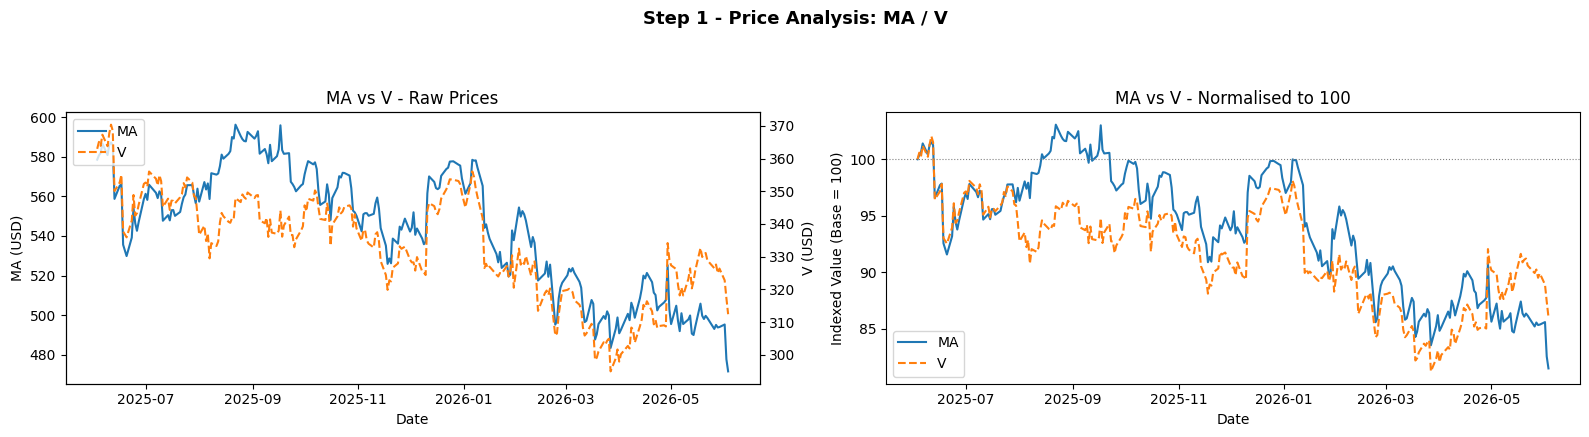

In [112]:
plot_prices(prices, A1, A2)

#### Step 2 — Correlation Analysis

In [113]:
results[(A1, A2)] = analyse_pair(prices,A1,A2,alpha=ALPHA)

r = results[(A1, A2)]

print(f"Pearson Correlation ({A1} vs {A2}): "
    f"{r['correlation']:.4f}"
)

Pearson Correlation (MA vs V): 0.8597


#### Step 3 — OLS Regression (Hedge Ratio Estimation)

In [114]:
r = results[(A1, A2)]

print(f"OLS: log({A1}) = {r['intercept']:.4f} + "f"{r['hedge_ratio']:.4f} × log({A2})")

print(f"Hedge Ratio (β) : {r['hedge_ratio']:.4f}")
print(f"R²              : {r['r_squared']:.4f}")
print()

print(r["ols_result"].summary())

OLS: log(MA) = 0.4326 + 1.0098 × log(V)
Hedge Ratio (β) : 1.0098
R²              : 0.7233

                            OLS Regression Results                            
Dep. Variable:                     MA   R-squared:                       0.723
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     653.4
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           1.07e-71
Time:                        12:54:58   Log-Likelihood:                 523.05
No. Observations:                 252   AIC:                            -1042.
Df Residuals:                     250   BIC:                            -1035.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

#### Step 4 — Spread Construction

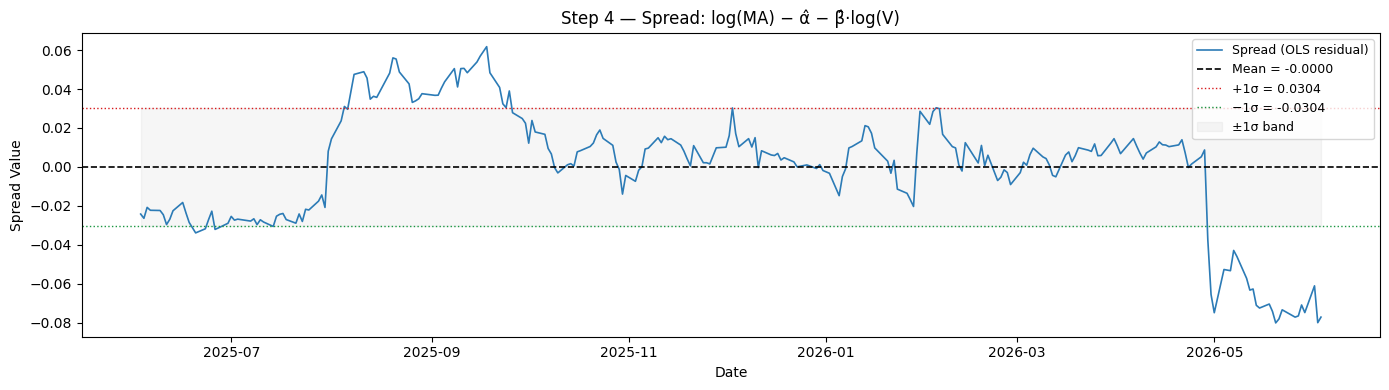

Spread summary — MA vs V
  Mean : -0.000000  (should be ≈ 0 for a well-specified model)
  Std  : 0.030424


In [115]:
r = results[(A1, A2)]

plot_spread(r["spread"], A1,A2)

print(f"Spread summary — {A1} vs {A2}")
print(
    f"  Mean : {r['spread_mean']:.6f}  "
    f"(should be ≈ 0 for a well-specified model)"
)
print(f"  Std  : {r['spread_std']:.6f}")

#### Step 5 — Engle-Granger Cointegration Test (ADF on Spread)

In [116]:
r = results[(A1, A2)]

print_adf_results(r, A1, A2)

══════════════════════════════════════════════════════════
  ADF TEST RESULTS — MA vs V
══════════════════════════════════════════════════════════
  H₀ : Spread has a unit root (non-stationary)
  H₁ : Spread is stationary (mean-reverting)
──────────────────────────────────────────────────────────
  ADF Test Statistic :    -1.1889
  p-value            :     0.6783
  Lags used (AIC)    :          0
  Observations       :        251
──────────────────────────────────────────────────────────
Critical Values:
    1%   :    -3.4567
    5%   :    -2.8731
    10%  :    -2.5729
──────────────────────────────────────────────────────────
  Verdict (α = 0.05) : NOT COINTEGRATED
══════════════════════════════════════════════════════════


#### Step 6 — Z-Score Analysis

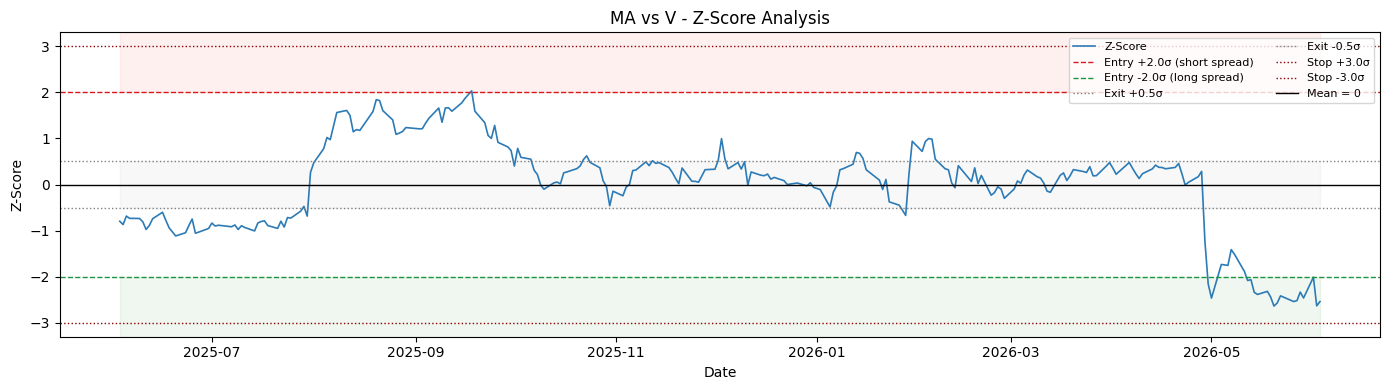

Z-Score Signal Statistics — MA vs V
  Mean              : -0.0000  (should be exactly 0)
  Std               : 1.0000   (should be exactly 1)
  Min               : -2.635
  Max               : 2.030
  Long signals  (z < −2.0σ) : 18 days
  Short signals (z > +2.0σ) : 1 days
  Neutral zone  (|z| < 0.5σ) : 50.4% of days


In [117]:
r = results[(A1, A2)]

plot_zscore(r["zscore"], A1, A2, z_entry=Z_ENTRY, z_exit=Z_EXIT, z_stop=Z_STOP)

print(f"Z-Score Signal Statistics — {A1} vs {A2}")
print(f"  Mean              : {r['zscore'].mean():.4f}  (should be exactly 0)")
print(f"  Std               : {r['zscore'].std():.4f}   (should be exactly 1)")
print(f"  Min               : {r['zscore_min']:.3f}")
print(f"  Max               : {r['zscore_max']:.3f}")
print(f"  Long signals  (z < −{Z_ENTRY:.1f}σ) : {r['n_long_signals']} days")
print(f"  Short signals (z > +{Z_ENTRY:.1f}σ) : {r['n_short_signals']} days")

pct_neutral = (
    (r['zscore'].abs() < Z_EXIT).sum()/ len(r['zscore'])* 100
)

print(
    f"  Neutral zone  (|z| < {Z_EXIT:.1f}σ) : "
    f"{pct_neutral:.1f}% of days"
)

#### Step 6.1 — Residual Diagnostics

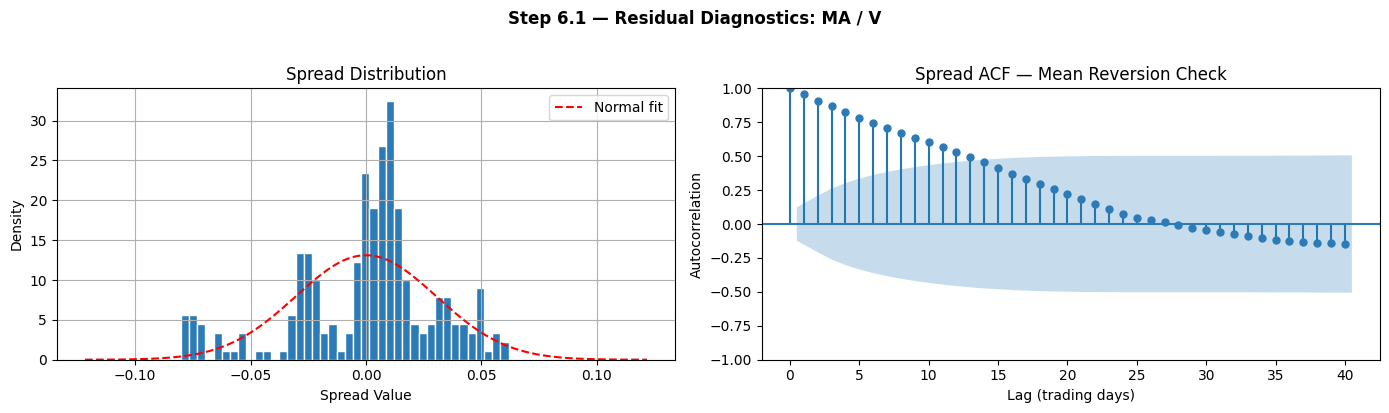

In [118]:
r = results[(A1, A2)]

plot_residual_diagnostics( r["spread"], A1, A2)

**Interpretation:** The spread distribution is centered close to zero, indicating no strong bias in the residual series. The ACF decays gradually from high positive values toward zero, suggesting persistence in the spread but evidence of mean-reverting behavior rather than a permanent trend. Temporary deviations between MA and V may create mean-reversion trading opportunities. Positions are entered at extreme z-scores and closed as the spread converges, with stop-loss limits protecting against structural changes in the relationship.


In [119]:
print(f"Pair {A1}/{A2} complete. Results stored.")

Pair MA/V complete. Results stored.


---
### Pair 2: HD vs LOW — Home Depot vs Lowe's

**Sector:** Consumer Discretionary — Home Improvement Retail
---

In [120]:
A1, A2 = "HD", "LOW"

#### Step 1 — Price Analysis

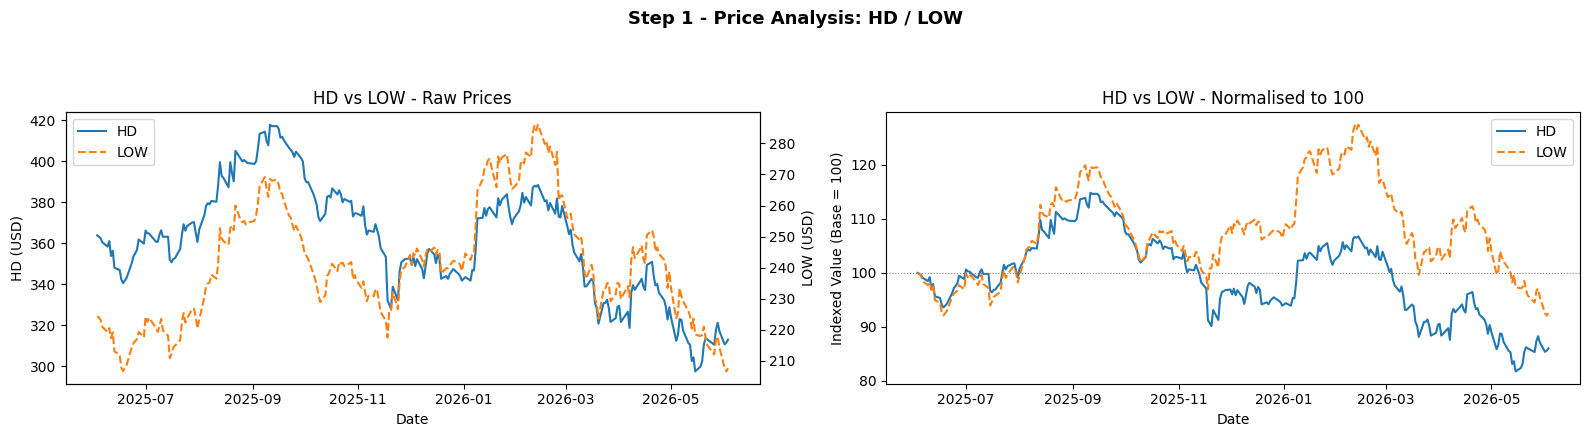

In [121]:
plot_prices(prices, A1, A2)

#### Step 2 — Correlation Analysis

In [122]:
results[(A1, A2)] = analyse_pair(prices, A1, A2, alpha=ALPHA)

r = results[(A1, A2)]

print(f"Pearson Correlation ({A1} vs {A2}): {r['correlation']:.4f}")

Pearson Correlation (HD vs LOW): 0.8808


#### Step 3 — OLS Regression (Hedge Ratio)

In [123]:
r = results[(A1, A2)]

print(f"OLS: log({A1}) = {r['intercept']:.4f} + {r['hedge_ratio']:.4f} × log({A2})")
print(f"Hedge Ratio (β) : {r['hedge_ratio']:.4f}")
print(f"R²              : {r['r_squared']:.4f}")
print()

print(r["ols_result"].summary())

OLS: log(HD) = 2.6079 + 0.5980 × log(LOW)
Hedge Ratio (β) : 0.5980
R²              : 0.3643

                            OLS Regression Results                            
Dep. Variable:                     HD   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     143.3
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           2.11e-26
Time:                        12:55:07   Log-Likelihood:                 348.70
No. Observations:                 252   AIC:                            -693.4
Df Residuals:                     250   BIC:                            -686.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

#### Step 4 — Spread Construction

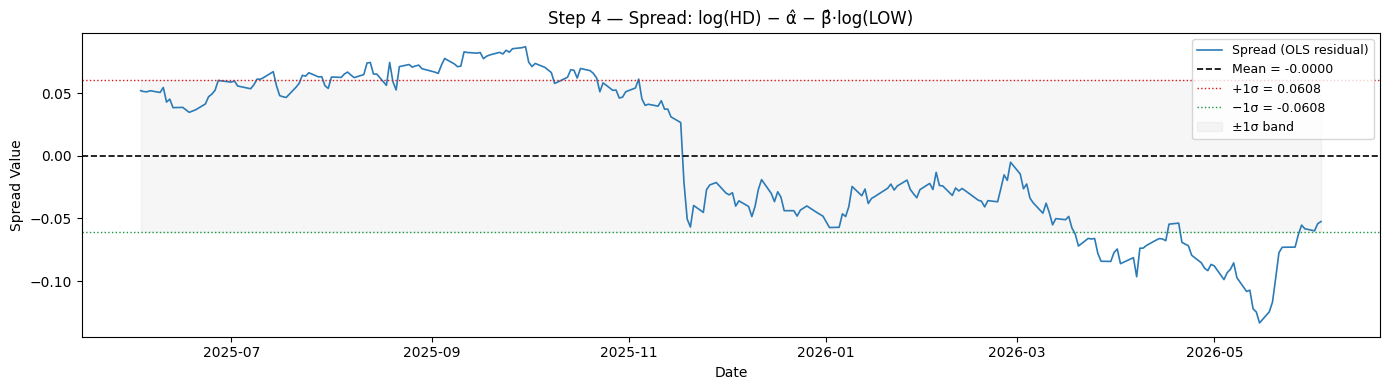

Spread summary — HD vs LOW
  Mean : -0.000000
  Std  : 0.060767


In [124]:
r = results[(A1, A2)]

plot_spread(r["spread"], A1, A2)

print(f"Spread summary — {A1} vs {A2}")
print(f"  Mean : {r['spread_mean']:.6f}")
print(f"  Std  : {r['spread_std']:.6f}")

#### Step 5 — Engle-Granger Cointegration Test

In [125]:
r = results[(A1, A2)]

print_adf_results(r, A1, A2)

══════════════════════════════════════════════════════════
  ADF TEST RESULTS — HD vs LOW
══════════════════════════════════════════════════════════
  H₀ : Spread has a unit root (non-stationary)
  H₁ : Spread is stationary (mean-reverting)
──────────────────────────────────────────────────────────
  ADF Test Statistic :    -1.0035
  p-value            :     0.7520
  Lags used (AIC)    :          0
  Observations       :        251
──────────────────────────────────────────────────────────
Critical Values:
    1%   :    -3.4567
    5%   :    -2.8731
    10%  :    -2.5729
──────────────────────────────────────────────────────────
  Verdict (α = 0.05) : NOT COINTEGRATED
══════════════════════════════════════════════════════════


#### Step 6 — Z-Score Analysis

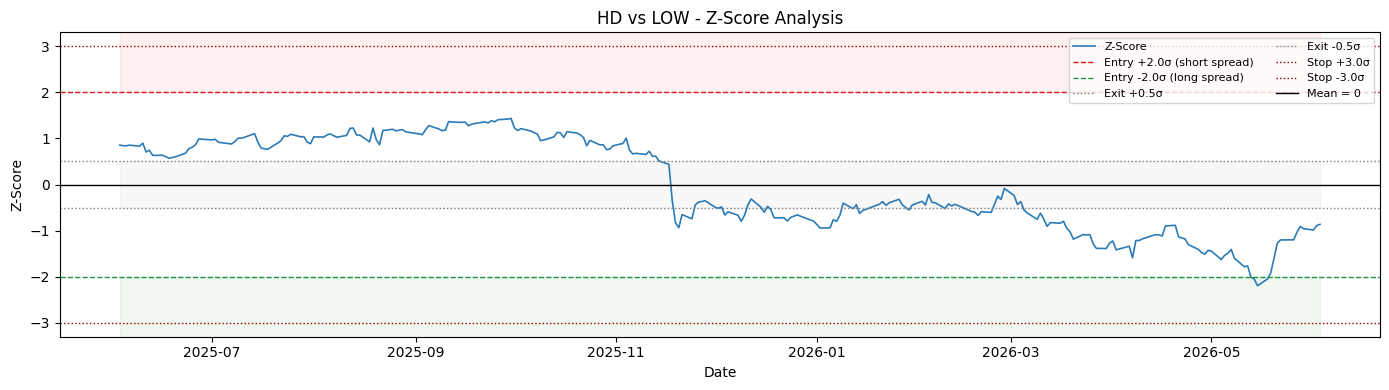

Z-Score Signal Statistics — HD vs LOW
  Long signals  (z < −2.0σ) : 4 days
  Short signals (z > +2.0σ) : 0 days


In [126]:
r = results[(A1, A2)]

plot_zscore( r["zscore"], A1, A2, z_entry=Z_ENTRY, z_exit=Z_EXIT, z_stop=Z_STOP)

print(f"Z-Score Signal Statistics — {A1} vs {A2}")
print(f"  Long signals  (z < −{Z_ENTRY:.1f}σ) : {r['n_long_signals']} days")
print(f"  Short signals (z > +{Z_ENTRY:.1f}σ) : {r['n_short_signals']} days")

#### Step 6.1 — Residual Diagnostics

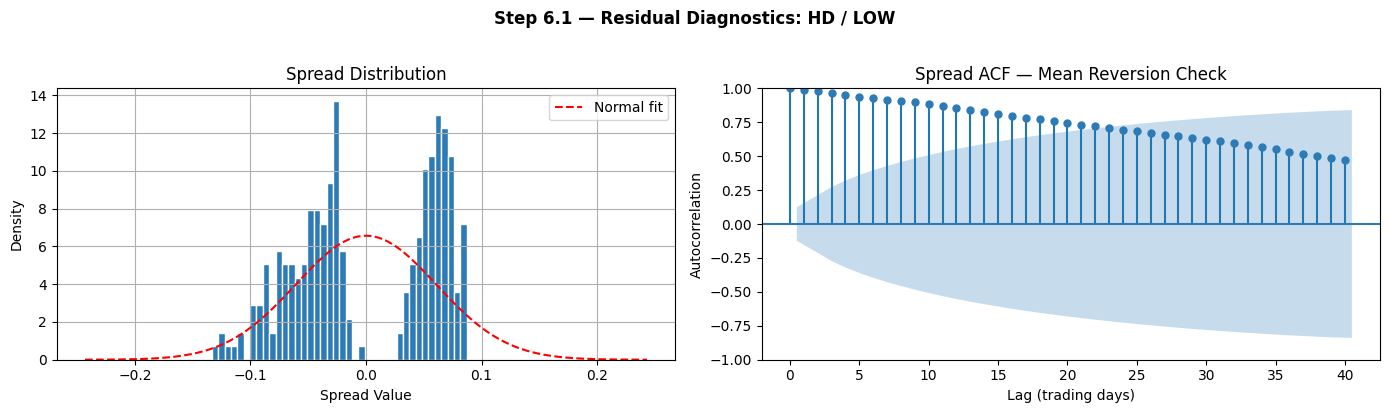

In [127]:
r = results[(A1, A2)]

plot_residual_diagnostics( r["spread"], A1, A2)

**Interpretation:** Home Depot and Lowe's have similar business models and are influenced by the same housing and consumer spending trends, making temporary price divergences potential mean-reversion opportunities. Positions are entered at extreme z-scores and closed as the spread converges, while stop-loss limits help protect against structural changes that could permanently alter the relationship.

In [128]:
print(f"Pair {A1}/{A2} complete. Results stored.")

Pair HD/LOW complete. Results stored.


---
### Pair 3: AMAT vs LRCX — Applied Materials vs Lam Research

**Sector:** Technology — Semiconductor Capital Equipment

---

In [129]:
A1, A2 = "AMAT", "LRCX"

#### Step 1 — Price Analysis

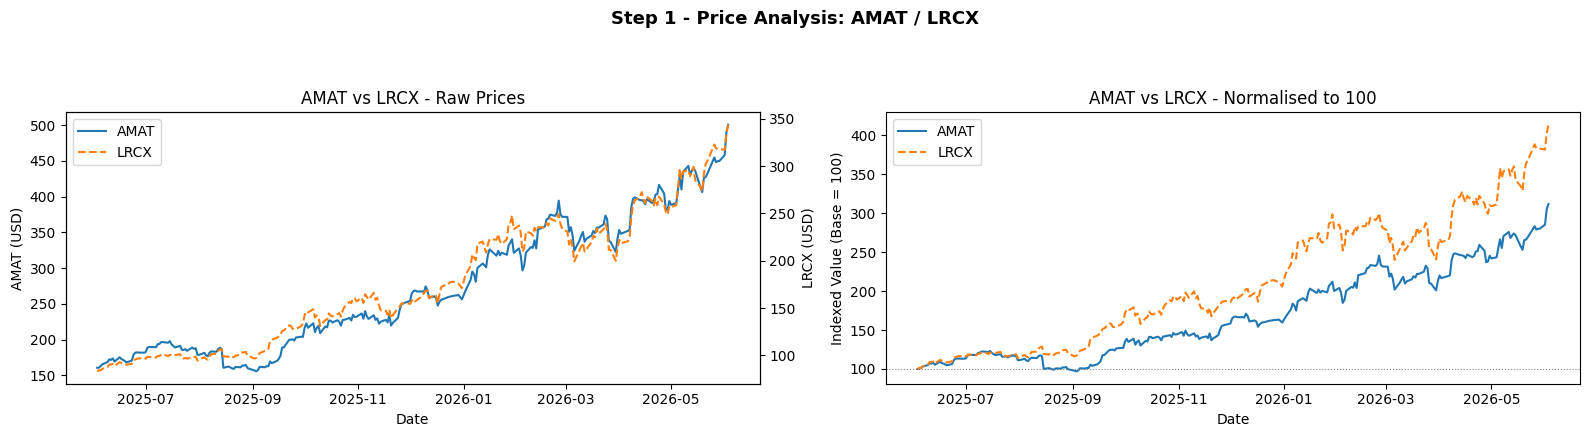

In [130]:
plot_prices(prices, A1, A2)

#### Step 2 — Correlation Analysis

In [131]:
results[(A1, A2)] = analyse_pair(prices, A1, A2, alpha=ALPHA)

r = results[(A1, A2)]

print(f"Pearson Correlation ({A1} vs {A2}): {r['correlation']:.4f}")

Pearson Correlation (AMAT vs LRCX): 0.8635


#### Step 3 — OLS Regression (Hedge Ratio)

In [132]:
r = results[(A1, A2)]

print(f"OLS: log({A1}) = {r['intercept']:.4f} + {r['hedge_ratio']:.4f} × log({A2})")
print(f"Hedge Ratio (β) : {r['hedge_ratio']:.4f}")
print(f"R²              : {r['r_squared']:.4f}")
print()

print(r["ols_result"].summary())

OLS: log(AMAT) = 1.4047 + 0.8150 × log(LRCX)
Hedge Ratio (β) : 0.8150
R²              : 0.9581

                            OLS Regression Results                            
Dep. Variable:                   AMAT   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     5712.
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          3.39e-174
Time:                        12:55:16   Log-Likelihood:                 323.31
No. Observations:                 252   AIC:                            -642.6
Df Residuals:                     250   BIC:                            -635.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

#### Step 4 — Spread Construction

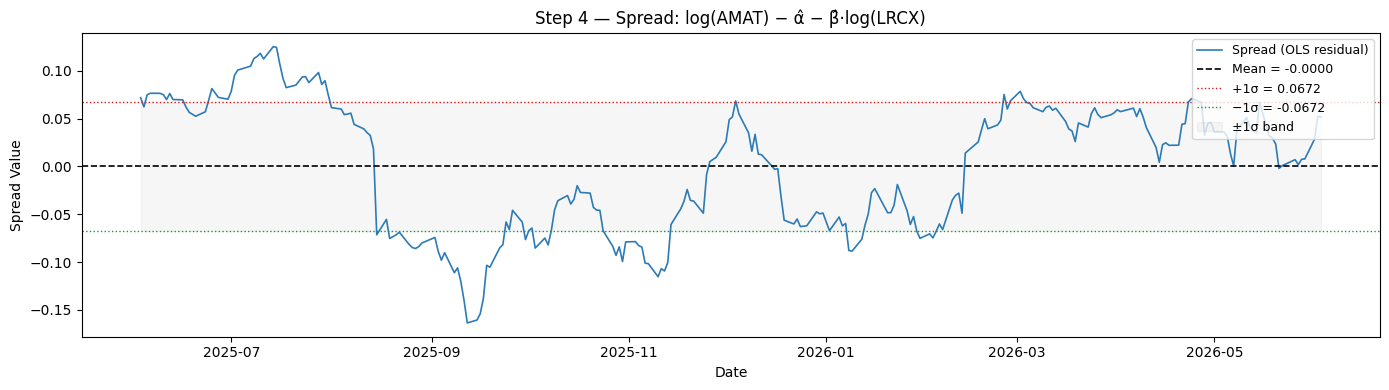

Spread summary — AMAT vs LRCX
  Mean : -0.000000
  Std  : 0.067210


In [133]:
r = results[(A1, A2)]

plot_spread( r["spread"], A1, A2)

print(f"Spread summary — {A1} vs {A2}")
print(f"  Mean : {r['spread_mean']:.6f}")
print(f"  Std  : {r['spread_std']:.6f}")

#### Step 5 — Engle-Granger Cointegration Test

In [134]:
r = results[(A1, A2)]

print_adf_results( r, A1, A2)

══════════════════════════════════════════════════════════
  ADF TEST RESULTS — AMAT vs LRCX
══════════════════════════════════════════════════════════
  H₀ : Spread has a unit root (non-stationary)
  H₁ : Spread is stationary (mean-reverting)
──────────────────────────────────────────────────────────
  ADF Test Statistic :    -1.8194
  p-value            :     0.3709
  Lags used (AIC)    :          0
  Observations       :        251
──────────────────────────────────────────────────────────
Critical Values:
    1%   :    -3.4567
    5%   :    -2.8731
    10%  :    -2.5729
──────────────────────────────────────────────────────────
  Verdict (α = 0.05) : NOT COINTEGRATED
══════════════════════════════════════════════════════════


#### Step 6 — Z-Score Analysis

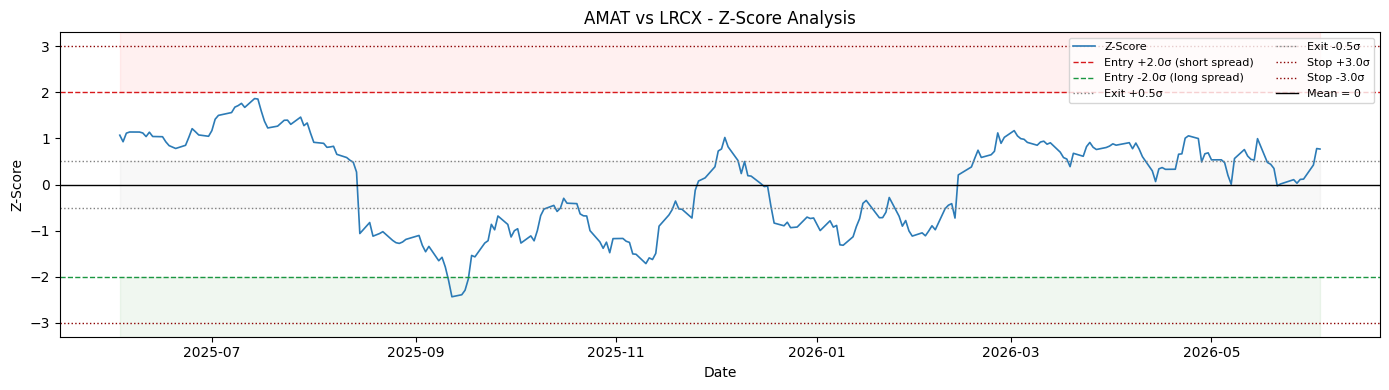

Z-Score Signal Statistics — AMAT vs LRCX
  Long signals  (z < −2.0σ) : 5 days
  Short signals (z > +2.0σ) : 0 days


In [135]:
r = results[(A1, A2)]

plot_zscore( r["zscore"], A1, A2, z_entry=Z_ENTRY, z_exit=Z_EXIT, z_stop=Z_STOP)

print(f"Z-Score Signal Statistics — {A1} vs {A2}")
print(f"  Long signals  (z < −{Z_ENTRY:.1f}σ) : {r['n_long_signals']} days")
print(f"  Short signals (z > +{Z_ENTRY:.1f}σ) : {r['n_short_signals']} days")

#### Step 6.1 — Residual Diagnostics

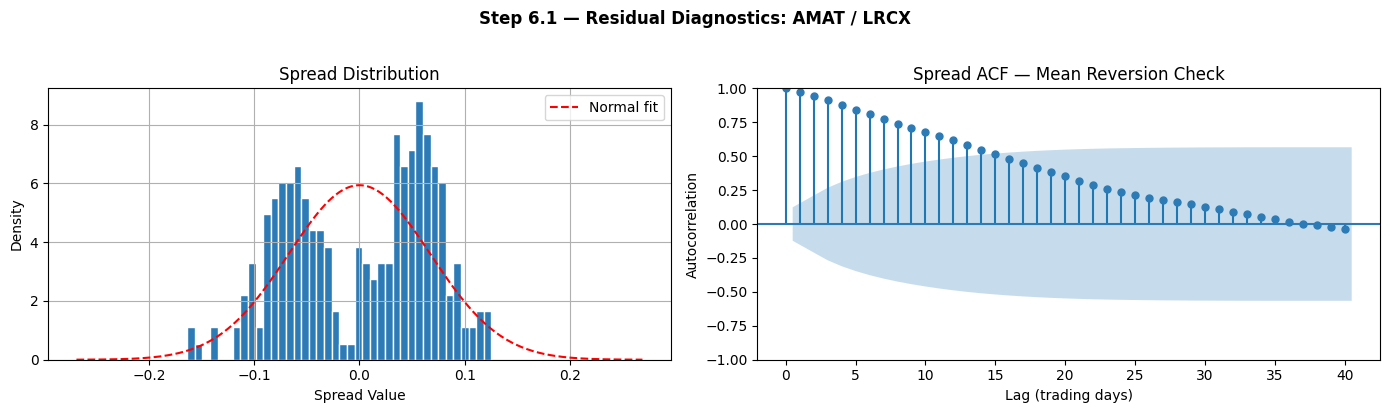

In [136]:
r = results[(A1, A2)]

plot_residual_diagnostics( r["spread"], A1,A2)

**Interpretation:** The spread distribution is centred near zero, indicating no strong long-term bias, although the shape deviates somewhat from a normal distribution. The ACF decays gradually from high positive values toward zero, suggesting the spread exhibits persistence but also evidence of mean-reverting behaviour over time.

In [137]:
print(f"Pair {A1}/{A2} complete. Results stored.")

Pair AMAT/LRCX complete. Results stored.
